# AfriAgri Survey Intelligence — Exploratory Data Analysis
**African Agrifood Intelligence Initiative**  
Regional Agrifood Research Consortium  
  
**Analyst:** Survey Research Team  
**Dataset:** 2,500 respondents | 56 variables | 5 African regions  
  
---
### Notebook Structure
1. Setup & data loading
2. Data overview & quality audit
3. Demographic profiles
4. Barrier analysis
5. Readiness & governance scores
6. Regional deep-dive
7. Organisation-type analysis
8. Gender-disaggregated analysis
9. Correlation & composite intelligence
10. Text insights (lessons learned & recommendations)
11. Key findings summary

## 1. Setup & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ── Styling ────────────────────────────────────────────────────────────────
AfriAgri_GREEN  = '#1D9E75'
AfriAgri_TEAL   = '#0F6E56'
AfriAgri_GOLD   = '#EF9F27'
AfriAgri_CORAL  = '#D85A30'
AfriAgri_PURPLE = '#7F77DD'
AfriAgri_GRAY   = '#888780'
AfriAgri_LIGHT  = '#E1F5EE'

REGION_PALETTE = {
    'West Africa':    AfriAgri_GREEN,
    'East Africa':    AfriAgri_TEAL,
    'Central Africa': AfriAgri_GOLD,
    'Southern Africa':AfriAgri_CORAL,
    'Northern Africa':AfriAgri_PURPLE,
}

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.color':       '#EEEEEE',
    'grid.linewidth':   0.6,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
})

print('Libraries loaded.')

Libraries loaded.


In [ ]:
# ── Load dataset ──────────────────────────────────────────────────────────
from google.colab import files
files.upload()  # upload AfriAgri_Survey_Dataset.xlsx
RAW_PATH = 'AfriAgri_Survey_Dataset.xlsx'
df_raw = pd.read_excel(RAW_PATH)

# ── Drop PII immediately ──────────────────────────────────────────────────
PII_COLS = ['Full_Name', 'Phone_Number', 'Email_Address']
df = df_raw.drop(columns=PII_COLS)

print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'PII columns dropped: {PII_COLS}')
df.head(3)

Saving AfriAgri_Survey_Dataset.xlsx to AfriAgri_Survey_Dataset.xlsx
Dataset loaded: 2,500 rows × 53 columns
PII columns dropped: ['Full_Name', 'Phone_Number', 'Email_Address']


,Respondent_ID,Age_Range,Gender,Disability_Status,Location_Type,Country,African_Region,Value_Chain,Organization_Name,Organization_Type,...,Hybrid_Platform_Readiness_Score,Strategic_Alignment_Score,Lessons_Learned_Text,Innovation_Recommendations_Text,Inclusivity_Recommendations_Text,Vulnerability_Index,Governance_Readiness_Score,Sustainability_Score,MELAR_Readiness_Score,Intervention_Priority
0,PAWA_00001,18-35,Female,No,Semi-Urban,Nigeria,West Africa,Agri-Finance,Martin Group,Government Agency,...,3,4,Climate adaptation training should be expanded,Support aggregation and funding of agricultura...,Increase disability-inclusive participation fr...,4.25,4.0,4.00,3.50,High
1,PAWA_00002,18-35,Female,No,Semi-Urban,Morocco,Northern Africa,Marketing,Porter-Nelson,Community Network,...,5,5,Technology adoption is improving productivity ...,Deploy mobile agricultural advisory platforms,Increase disability-inclusive participation fr...,3.50,4.0,3.75,3.75,Moderate
2,PAWA_00003,18-35,Female,Yes,Rural,Cameroon,Central Africa,Services,"Garza, Mitchell and Williams",Government Agency,...,5,4,Need stronger digital extension systems for wo...,Introduce AI-supported climate monitoring systems,Strengthen gender-responsive technology access,4.50,3.5,4.00,4.00,Critical


## 2. Data Overview & Quality Audit

In [ ]:
# ── Column type inventory ─────────────────────────────────────────────────
cat_cols    = df.select_dtypes('object').columns.tolist()
int_cols    = df.select_dtypes('int64').columns.tolist()
float_cols  = df.select_dtypes('float64').columns.tolist()

print(f'Categorical columns ({len(cat_cols)}):  {cat_cols}')
print(f'Integer score columns ({len(int_cols)}): {int_cols}')
print(f'Float computed columns ({len(float_cols)}): {float_cols}')

Categorical columns (15):  ['Respondent_ID', 'Age_Range', 'Gender', 'Disability_Status', 'Location_Type', 'Country', 'African_Region', 'Value_Chain', 'Organization_Name', 'Organization_Type', 'Reporting_Level', 'Lessons_Learned_Text', 'Innovation_Recommendations_Text', 'Inclusivity_Recommendations_Text', 'Intervention_Priority']
Integer score columns (34): ['Complement_Existing_Platforms_Score', 'Framework_Inclusivity_Score', 'Governance_Transparency_Score', 'Membership_Clarity_Score', 'Stakeholder_Participation_Score', 'Trust_Building_Score', 'Finance_Barrier_Score', 'Land_Access_Barrier_Score', 'Climate_Risk_Score', 'Technology_Barrier_Score', 'Funding_Support_Need', 'Land_Ownership_Importance', 'Early_Warning_Importance', 'Capacity_Building_Need', 'Technology_Intervention_Need', 'KPI_Alignment_Score', 'Impact_Measurement_Score', 'Gender_Data_Promotion_Score', 'Continuous_Learning_Score', 'Resource_Mobilization_Score', 'Funding_Diversification_Score', 'Partnership_Strategy_Score', 'K

In [ ]:
# ── Null audit ────────────────────────────────────────────────────────────
null_counts = df.isnull().sum()
print('Null values per column:')
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else 'None — dataset is complete.')

# ── Duplicate check
dupes = df.duplicated().sum()
print(f'\nDuplicate rows: {dupes}')

# ── Score range validation
score_cols_1to5 = int_cols  # all integer cols are 1–5 scores
out_of_range = {c: ((df[c] < 1) | (df[c] > 5)).sum() for c in score_cols_1to5}
print('\nOut-of-range values (score cols):')
print({k:v for k,v in out_of_range.items() if v > 0} or 'None — all scores within 1–5 range.')

Null values per column:
None — dataset is complete.

Duplicate rows: 0

Out-of-range values (score cols):
{'Government_Partner': np.int64(1181), 'Private_Sector_Partner': np.int64(1191), 'International_Org_Partner': np.int64(1272), 'Academia_Partner': np.int64(1261), 'Farmers_Association_Partner': np.int64(1296), 'CSO_Partner': np.int64(1219)}


In [ ]:
# ── Statistical summary of score columns ─────────────────────────────────
df[int_cols].describe().T.sort_values('mean', ascending=False).round(2)

,count,mean,std,min,25%,50%,75%,max
Funding_Support_Need,2500.0,4.41,0.65,2.0,4.0,4.0,5.0,5.0
Capacity_Building_Need,2500.0,4.34,0.67,2.0,4.0,4.0,5.0,5.0
Women_Involvement_Score,2500.0,4.26,0.69,2.0,4.0,4.0,5.0,5.0
Gender_Data_Promotion_Score,2500.0,4.17,0.69,2.0,4.0,4.0,5.0,5.0
Land_Ownership_Importance,2500.0,4.15,0.71,2.0,4.0,4.0,5.0,5.0
Knowledge_Sharing_Score,2500.0,4.09,0.72,2.0,4.0,4.0,5.0,5.0
Framework_Inclusivity_Score,2500.0,4.09,0.71,2.0,4.0,4.0,5.0,5.0
Technology_Intervention_Need,2500.0,4.09,0.71,2.0,4.0,4.0,5.0,5.0
Strategic_Alignment_Score,2500.0,4.01,0.71,2.0,4.0,4.0,4.0,5.0
Impact_Measurement_Score,2500.0,4.00,0.71,2.0,4.0,4.0,4.0,5.0


## 3. Demographic Profiles

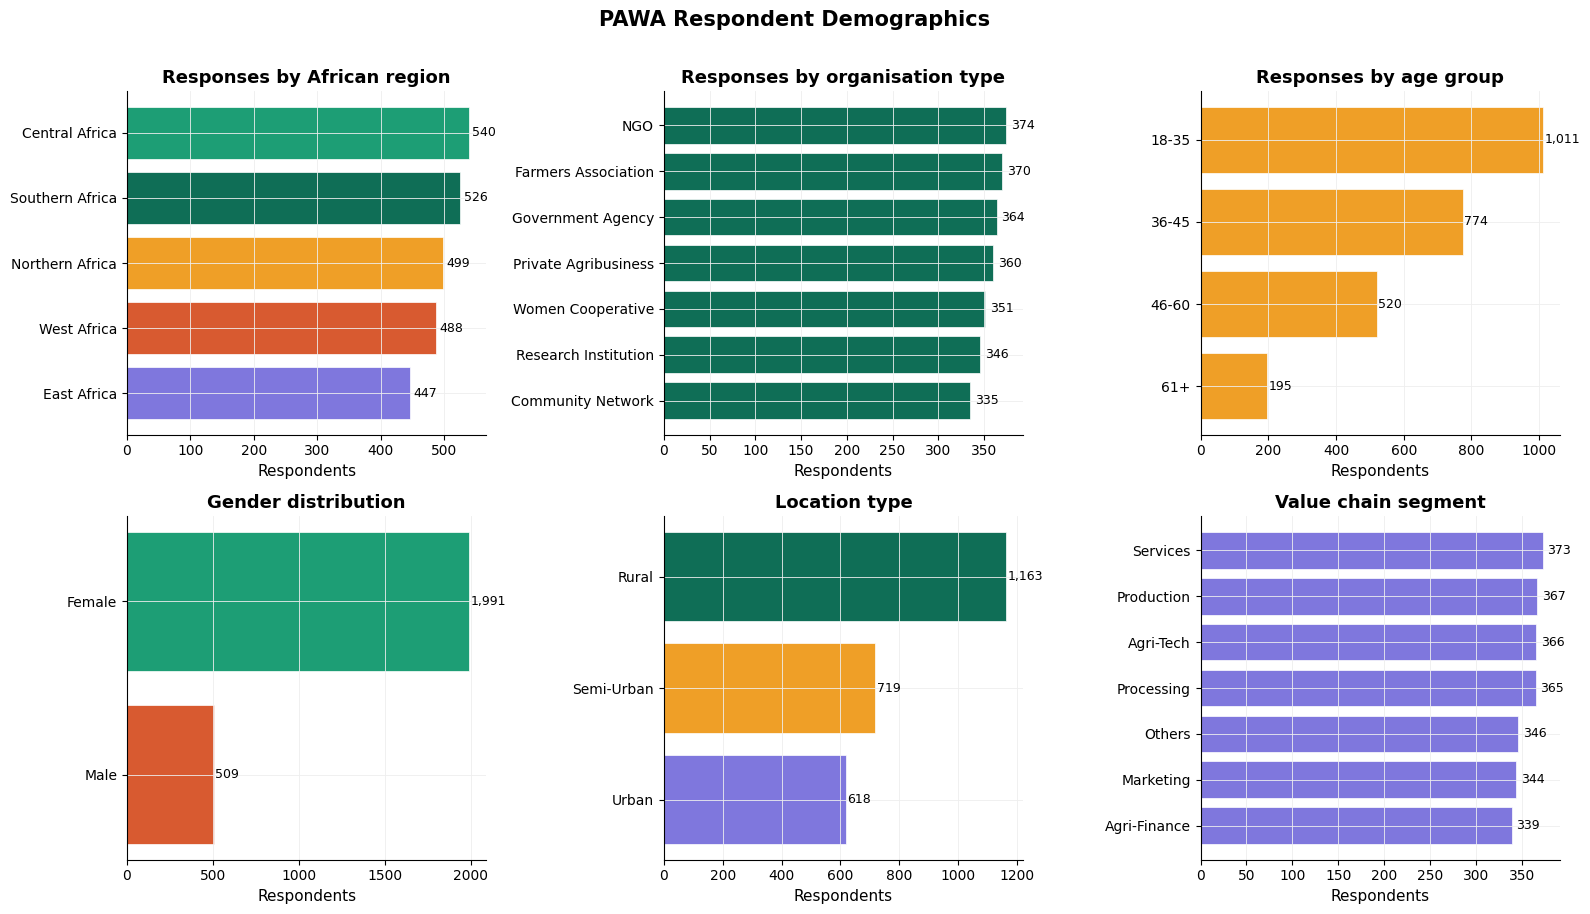

Figure saved: fig_01_demographics.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('AfriAgri Respondent Demographics', fontsize=15, fontweight='bold', y=1.01)

demo_fields = [
    ('African_Region',    'Responses by African region',  list(REGION_PALETTE.values())),
    ('Organization_Type', 'Responses by organisation type', AfriAgri_TEAL),
    ('Age_Range',         'Responses by age group',       AfriAgri_GOLD),
    ('Gender',            'Gender distribution',          [AfriAgri_GREEN, AfriAgri_CORAL]),
    ('Location_Type',     'Location type',                [AfriAgri_TEAL, AfriAgri_GOLD, AfriAgri_PURPLE]),
    ('Value_Chain',       'Value chain segment',          AfriAgri_PURPLE),
]

for ax, (col, title, color) in zip(axes.flat, demo_fields):
    counts = df[col].value_counts()
    bars = ax.barh(counts.index, counts.values,
                   color=color if isinstance(color, list) else [color]*len(counts),
                   edgecolor='white', linewidth=0.5)
    ax.set_title(title)
    ax.set_xlabel('Respondents')
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 5, bar.get_y() + bar.get_height()/2,
                f'{int(w):,}', va='center', fontsize=9)
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('fig_01_demographics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_01_demographics.png')

In [ ]:
# ── Disability status breakdown ───────────────────────────────────────────
disability = df['Disability_Status'].value_counts()
print('Disability status:')
print(disability)
print(f'\nRespondents with disability: {disability.get("Yes", 0)} '
      f'({disability.get("Yes", 0)/len(df)*100:.1f}%)')

Disability status:
Disability_Status
No     2231
Yes     269
Name: count, dtype: int64

Respondents with disability: 269 (10.8%)


## 4. Barrier Analysis
> Finance, land access, climate risk, and technology barriers are AfriAgri's primary diagnostic levers.

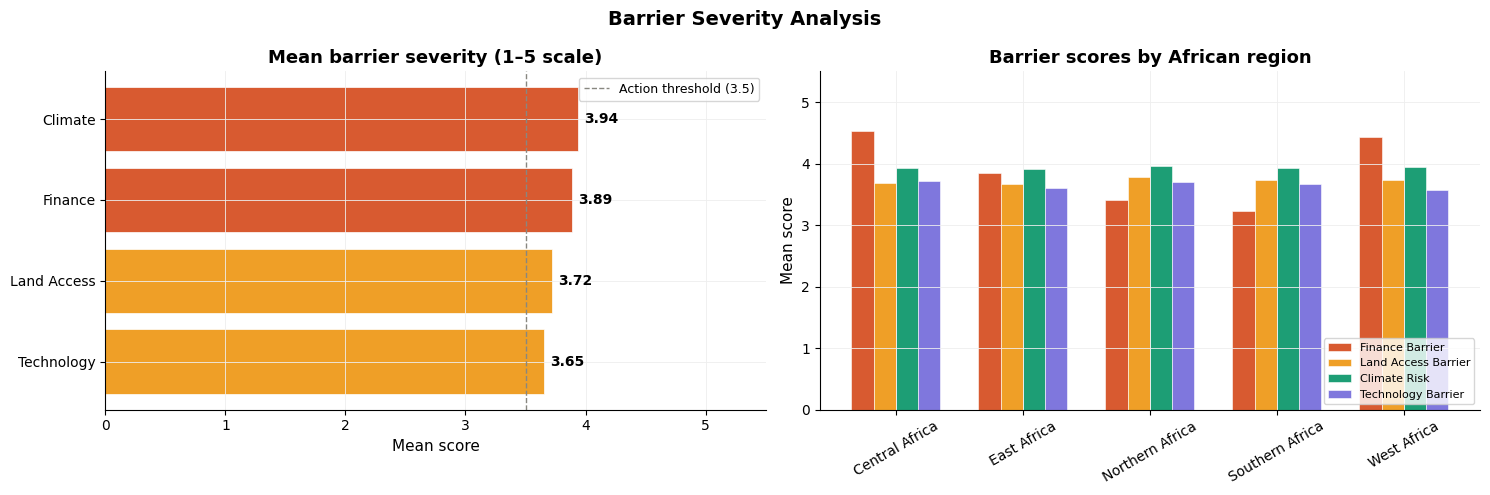

Figure saved: fig_02_barriers.png


In [ ]:
BARRIER_COLS = [
    'Finance_Barrier_Score',
    'Land_Access_Barrier_Score',
    'Climate_Risk_Score',
    'Technology_Barrier_Score',
]

barrier_means = df[BARRIER_COLS].mean().sort_values(ascending=True)
barrier_labels = [
    c.replace('_Barrier_Score','').replace('_Risk_Score','').replace('_',' ')
    for c in barrier_means.index
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Barrier Severity Analysis', fontsize=14, fontweight='bold')

# ── Overall mean barrier scores ───────────────────────────────────────────
colors = [AfriAgri_CORAL if v >= 3.8 else AfriAgri_GOLD if v >= 3.5 else AfriAgri_GREEN
          for v in barrier_means.values]
bars = axes[0].barh(barrier_labels, barrier_means.values, color=colors,
                    edgecolor='white', linewidth=0.5)
axes[0].set_xlim(0, 5.5)
axes[0].axvline(3.5, color=AfriAgri_GRAY, linestyle='--', linewidth=1, label='Action threshold (3.5)')
axes[0].set_title('Mean barrier severity (1–5 scale)')
axes[0].set_xlabel('Mean score')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, barrier_means.values):
    axes[0].text(val + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=10, fontweight='bold')

# ── Barrier scores by region ──────────────────────────────────────────────
barrier_by_region = df.groupby('African_Region')[BARRIER_COLS].mean()
barrier_by_region.plot(kind='bar', ax=axes[1],
                       color=[AfriAgri_CORAL, AfriAgri_GOLD, AfriAgri_GREEN, AfriAgri_PURPLE],
                       edgecolor='white', linewidth=0.4, width=0.7)
axes[1].set_title('Barrier scores by African region')
axes[1].set_xlabel('')
axes[1].set_ylabel('Mean score')
axes[1].set_ylim(0, 5.5)
axes[1].legend(
    [c.replace('_Score','').replace('_',' ') for c in BARRIER_COLS],
    fontsize=8, loc='lower right'
)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('fig_02_barriers.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_02_barriers.png')

In [ ]:
# ── High-severity barrier counts (score ≥ 4) per region ──────────────────
print('Respondents rating each barrier ≥ 4 (high severity):')
high_barrier = pd.DataFrame({
    col: (df.groupby('African_Region')[col].apply(lambda x: (x >= 4).sum()))
    for col in BARRIER_COLS
})
high_barrier.columns = [c.replace('_Score','').replace('_',' ') for c in BARRIER_COLS]
print(high_barrier.to_string())

Respondents rating each barrier ≥ 4 (high severity):
                 Finance Barrier  Land Access Barrier  Climate Risk  Technology Barrier
African_Region                                                                         
Central Africa               503                  310           376                 323
East Africa                  305                  262           313                 242
Northern Africa              222                  312           353                 303
Southern Africa              182                  315           374                 309
West Africa                  449                  293           341                 277


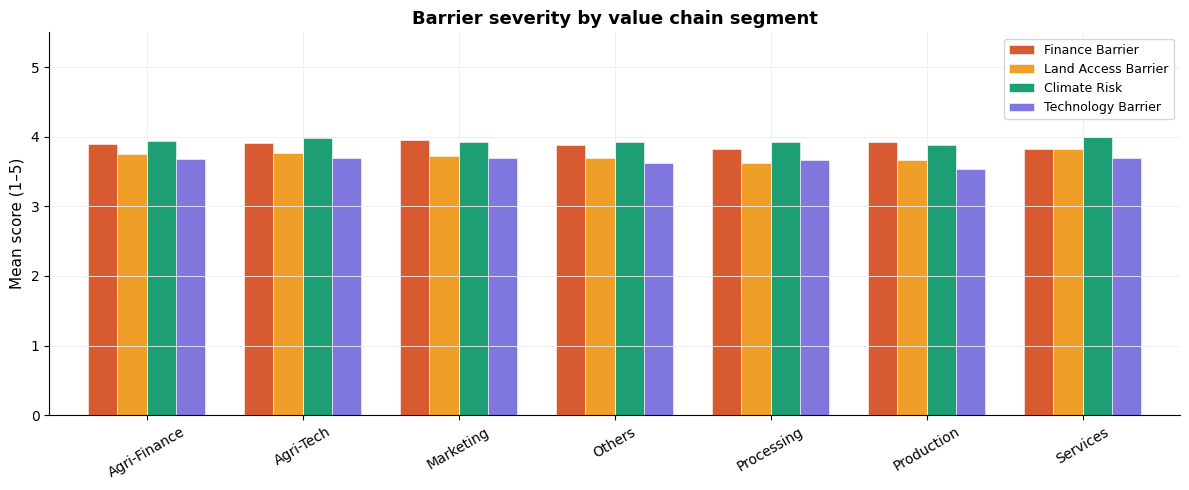

In [ ]:
# ── Barrier scores by value chain ─────────────────────────────────────────
barrier_by_vc = df.groupby('Value_Chain')[BARRIER_COLS].mean().round(2)
barrier_by_vc.columns = [c.replace('_Score','').replace('_',' ') for c in BARRIER_COLS]

fig, ax = plt.subplots(figsize=(12, 5))
barrier_by_vc.plot(kind='bar', ax=ax,
                   color=[AfriAgri_CORAL, AfriAgri_GOLD, AfriAgri_GREEN, AfriAgri_PURPLE],
                   edgecolor='white', linewidth=0.4, width=0.75)
ax.set_title('Barrier severity by value chain segment', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Mean score (1–5)')
ax.set_ylim(0, 5.5)
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_03_barriers_by_valuechain.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Readiness & Governance Scores

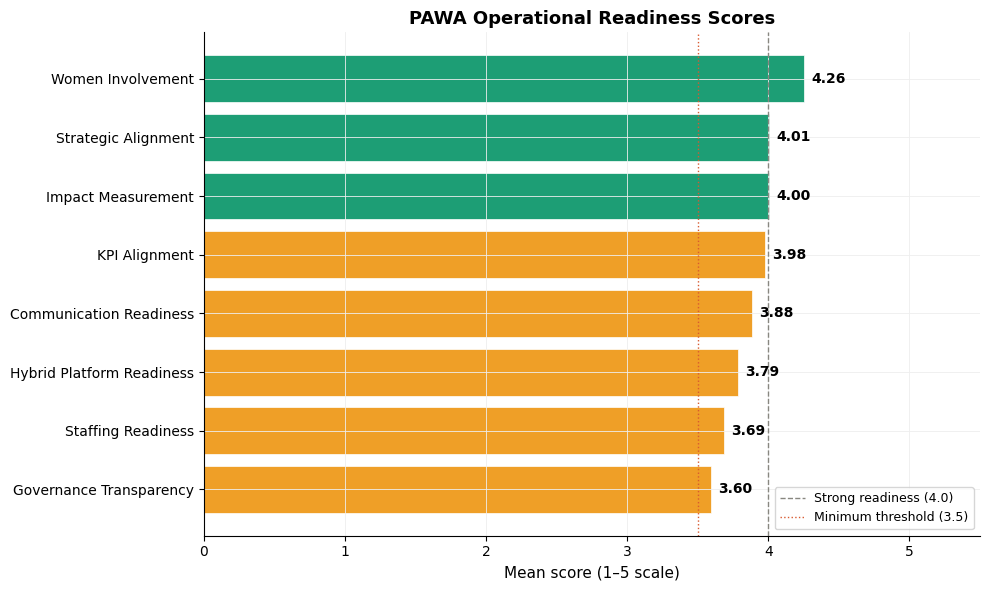

In [ ]:
READINESS_COLS = [
    'Staffing_Readiness_Score',
    'Communication_Readiness_Score',
    'Women_Involvement_Score',
    'Hybrid_Platform_Readiness_Score',
    'Strategic_Alignment_Score',
    'KPI_Alignment_Score',
    'Impact_Measurement_Score',
    'Governance_Transparency_Score',
]

readiness_means = df[READINESS_COLS].mean().sort_values()
readiness_labels = [c.replace('_Score','').replace('_',' ') for c in readiness_means.index]

fig, ax = plt.subplots(figsize=(10, 6))
colors = [AfriAgri_GREEN if v >= 4.0 else AfriAgri_GOLD if v >= 3.5 else AfriAgri_CORAL
          for v in readiness_means.values]
bars = ax.barh(readiness_labels, readiness_means.values, color=colors,
               edgecolor='white', linewidth=0.5)
ax.set_xlim(0, 5.5)
ax.axvline(4.0, color=AfriAgri_GRAY, linestyle='--', linewidth=1, label='Strong readiness (4.0)')
ax.axvline(3.5, color=AfriAgri_CORAL, linestyle=':', linewidth=1, label='Minimum threshold (3.5)')
ax.set_title('AfriAgri Operational Readiness Scores', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean score (1–5 scale)')
ax.legend(fontsize=9)
for bar, val in zip(bars, readiness_means.values):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_04_readiness.png', dpi=150, bbox_inches='tight')
plt.show()

### Explanation of AfriAgri Operational Readiness Scores

This horizontal bar chart illustrates the mean scores (on a 1-5 scale, where 5 is highest readiness) for various operational readiness aspects reported by AfriAgri's respondents. The visualization aims to highlight areas of strength and those requiring attention.

**Key Observations:**

*   **Women Involvement** and **Strategic Alignment** show the highest readiness scores, both averaging over 4.0, indicating strong performance in these areas.
*   **Governance Transparency**, **Staffing Readiness**, and **Hybrid Platform Readiness** are identified as areas with the lowest mean scores, falling below the 'Minimum threshold' of 3.5. This suggests these are critical areas for intervention.
*   The **green bars** indicate scores of 4.0 or higher, representing 'Strong readiness'.
*   The **gold bars** represent scores between 3.5 and 4.0, indicating moderate readiness that could benefit from improvement.
*   The **coral bars** signify scores below 3.5, highlighting areas where readiness is below the 'Minimum threshold' and requires urgent attention.

**Thresholds:**

*   A dashed **grey vertical line at 4.0** marks the benchmark for 'Strong readiness'.
*   A dotted **coral vertical line at 3.5** represents the 'Minimum threshold' for acceptable readiness.

### Detailed Explanation of Individual Readiness Scores

Each readiness score reflects an organization's capacity and preparedness in a specific area, measured on a 1-5 scale (1 = lowest readiness, 5 = highest readiness):

*   **Women Involvement:** This score indicates the extent to which women are meaningfully included, represented, and empowered within the organization's activities, decision-making processes, and leadership structures.

*   **Strategic Alignment:** This score measures how well the organization's daily operations, projects, and initiatives are aligned with its overarching strategic goals and mission. A high score suggests clear direction and cohesive effort.

*   **Impact Measurement:** This score assesses the organization's capability to systematically track, evaluate, and report the tangible effects and outcomes of its programs and interventions. It indicates the rigor of their monitoring, evaluation, and learning systems.

*   **KPI Alignment:** This refers to how effectively Key Performance Indicators (KPIs) are defined and utilized to measure progress towards strategic objectives. A high score implies that performance metrics are well-chosen and directly link to desired outcomes.

*   **Communication Readiness:** This score reflects the organization's capacity for effective internal and external communication, including the availability of clear channels, timely information dissemination, and engagement with stakeholders.

*   **Hybrid Platform Readiness:** This measures the organization's preparedness and ability to effectively operate across both physical (on-the-ground) and digital platforms, adapting to modern operational demands and leveraging technology.

*   **Staffing Readiness:** This score evaluates the organization's human resource capacity, including the availability of adequately skilled personnel, appropriate staffing levels, and effective talent management to meet operational needs.

*   **Governance Transparency:** This score assesses the clarity, openness, and accountability of the organization's governance structures, decision-making processes, and reporting mechanisms. A high score signifies strong ethical practices and trust.

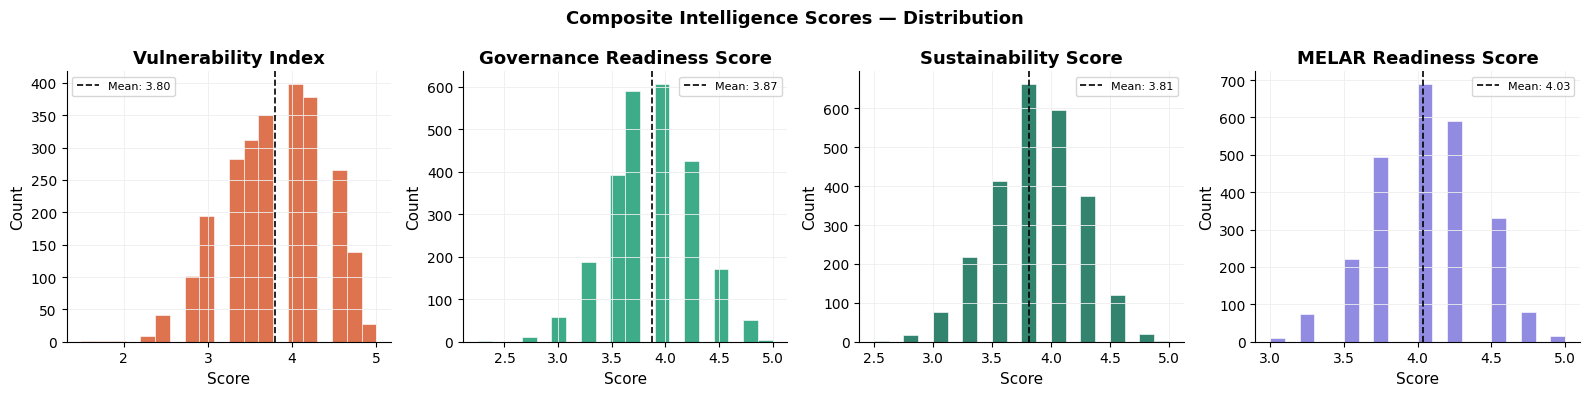

In [ ]:
# ── Computed composite scores distribution ────────────────────────────────
COMPOSITE_COLS = [
    'Vulnerability_Index',
    'Governance_Readiness_Score',
    'Sustainability_Score',
    'MELAR_Readiness_Score',
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Composite Intelligence Scores — Distribution', fontsize=13, fontweight='bold')

palette = [AfriAgri_CORAL, AfriAgri_GREEN, AfriAgri_TEAL, AfriAgri_PURPLE]

for ax, col, color in zip(axes, COMPOSITE_COLS, palette):
    ax.hist(df[col], bins=20, color=color, edgecolor='white', linewidth=0.5, alpha=0.85)
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'Mean: {df[col].mean():.2f}')
    ax.set_title(col.replace('_',' '))
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_05_composite_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Regional Deep-Dive

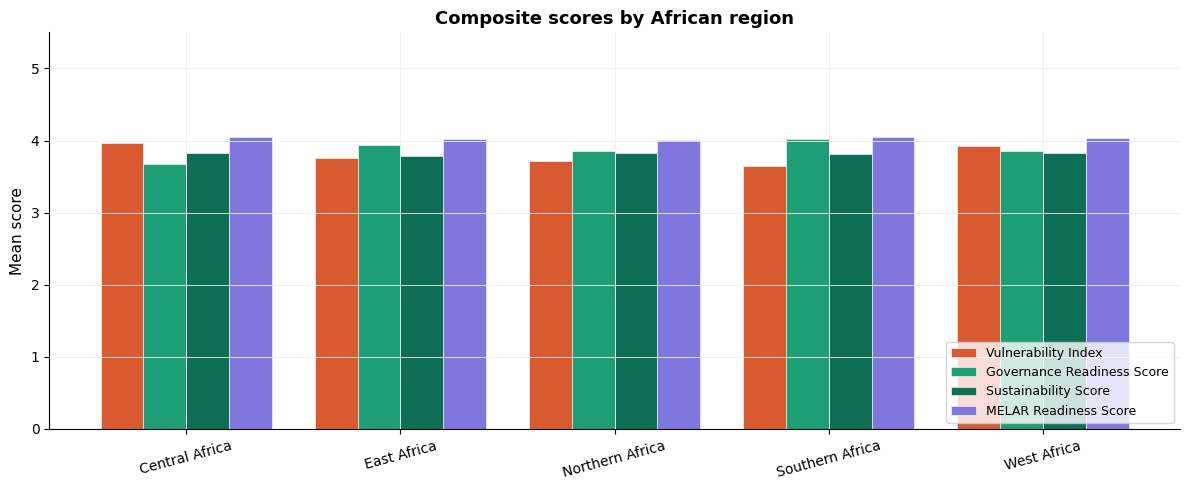


Regional composite scores table:
                 Vulnerability_Index  Governance_Readiness_Score  Sustainability_Score  MELAR_Readiness_Score
African_Region                                                                                               
Central Africa                  3.97                        3.68                  3.83                   4.05
East Africa                     3.76                        3.94                  3.79                   4.02
Northern Africa                 3.71                        3.86                  3.82                   4.01
Southern Africa                 3.64                        4.02                  3.81                   4.05
West Africa                     3.92                        3.86                  3.82                   4.03


In [ ]:
# ── Regional composite score comparison ───────────────────────────────────
region_composite = df.groupby('African_Region')[COMPOSITE_COLS].mean().round(2)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(region_composite))
width = 0.2
colors = [AfriAgri_CORAL, AfriAgri_GREEN, AfriAgri_TEAL, AfriAgri_PURPLE]

for i, (col, color) in enumerate(zip(COMPOSITE_COLS, colors)):
    bars = ax.bar(x + i*width, region_composite[col], width,
                  label=col.replace('_',' '), color=color,
                  edgecolor='white', linewidth=0.4)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(region_composite.index, rotation=15)
ax.set_ylim(0, 5.5)
ax.set_title('Composite scores by African region', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean score')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('fig_06_regional_composite.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nRegional composite scores table:')
print(region_composite.to_string())

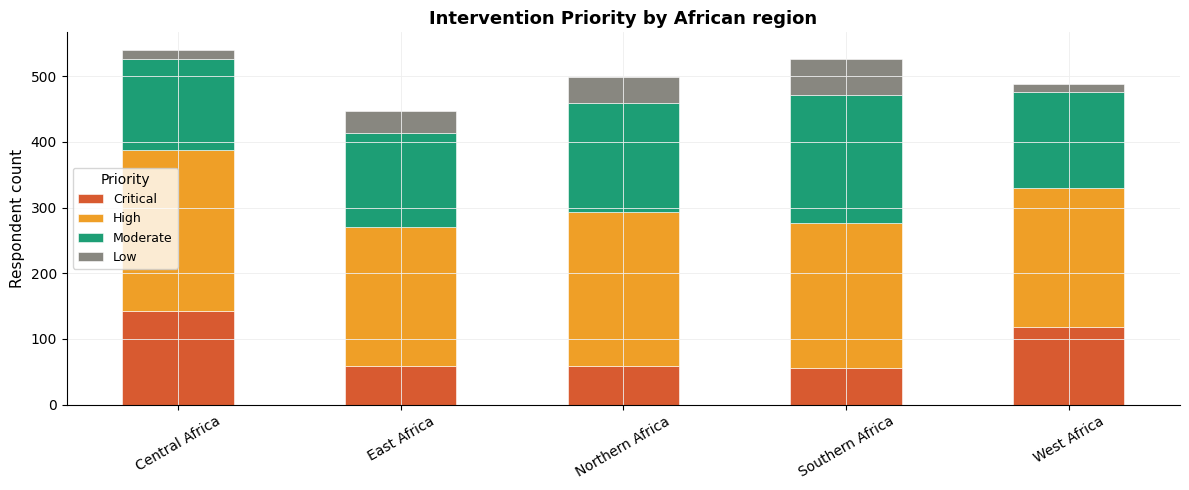

In [ ]:
# ── Intervention Priority by region ───────────────────────────────────────
priority_region = (
    df.groupby(['African_Region', 'Intervention_Priority'])
      .size().unstack(fill_value=0)
)
priority_order = ['Critical', 'High', 'Moderate', 'Low']
priority_region = priority_region.reindex(columns=priority_order, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
priority_region.plot(
    kind='bar', ax=ax, stacked=True,
    color=[AfriAgri_CORAL, AfriAgri_GOLD, AfriAgri_GREEN, AfriAgri_GRAY],
    edgecolor='white', linewidth=0.4
)
ax.set_title('Intervention Priority by African region', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Respondent count')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Priority', fontsize=9)
plt.tight_layout()
plt.savefig('fig_07_intervention_priority_region.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Organisation-Type Analysis

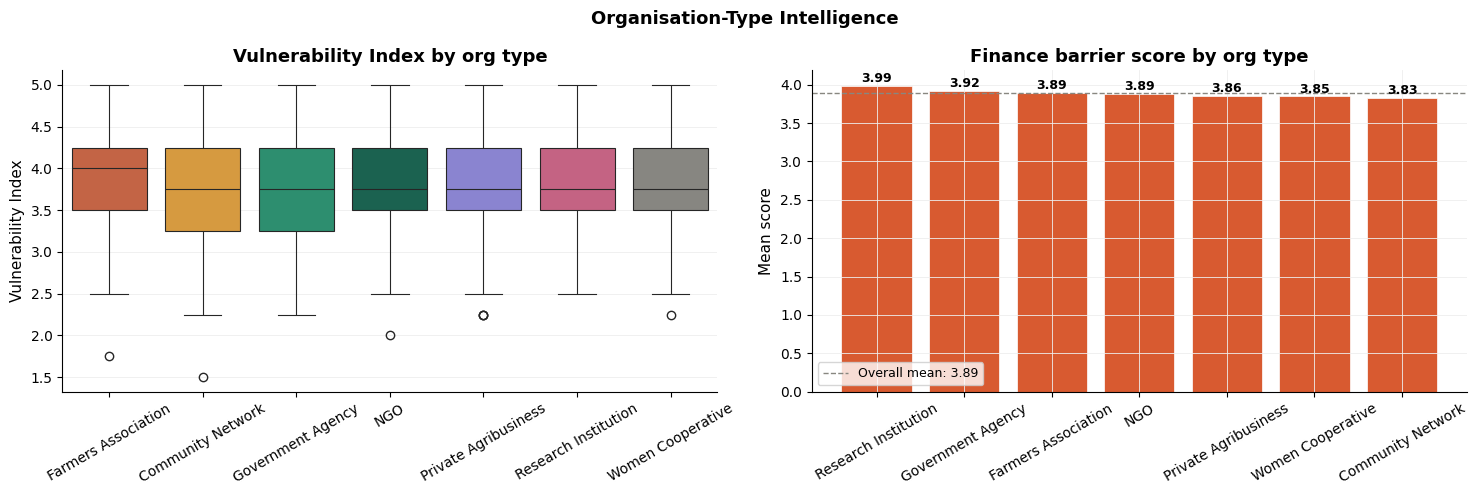

In [ ]:
# ── Vulnerability Index by organisation type ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Organisation-Type Intelligence', fontsize=13, fontweight='bold')

# Vulnerability boxplot
org_order = df.groupby('Organization_Type')['Vulnerability_Index'].median().sort_values(ascending=False).index
df_plot = df.set_index('Organization_Type').loc[org_order].reset_index()
sns.boxplot(
    data=df_plot, x='Organization_Type', y='Vulnerability_Index',
    palette=[AfriAgri_CORAL, AfriAgri_GOLD, AfriAgri_GREEN, AfriAgri_TEAL, AfriAgri_PURPLE, '#D4537E', '#888780'],
    ax=axes[0], order=org_order, linewidth=0.8
)
axes[0].set_title('Vulnerability Index by org type')
axes[0].set_xlabel('')
axes[0].set_ylabel('Vulnerability Index')
axes[0].tick_params(axis='x', rotation=30)

# Finance barrier mean by org type
finance_by_org = df.groupby('Organization_Type')['Finance_Barrier_Score'].mean().sort_values(ascending=False)
axes[1].bar(finance_by_org.index, finance_by_org.values,
            color=[AfriAgri_CORAL if v >= 3.8 else AfriAgri_GOLD if v >= 3.5 else AfriAgri_GREEN
                   for v in finance_by_org.values],
            edgecolor='white', linewidth=0.5)
axes[1].axhline(finance_by_org.mean(), color=AfriAgri_GRAY, linestyle='--',
                linewidth=1, label=f'Overall mean: {finance_by_org.mean():.2f}')
axes[1].set_title('Finance barrier score by org type')
axes[1].set_xlabel('')
axes[1].set_ylabel('Mean score')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(fontsize=9)
for i, (name, val) in enumerate(finance_by_org.items()):
    axes[1].text(i, val + 0.05, f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_08_org_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

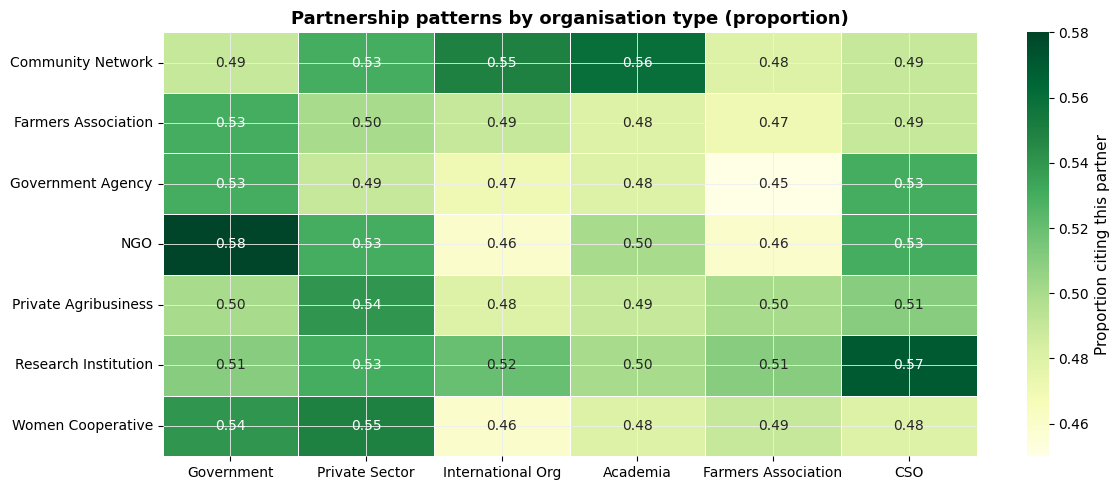

In [ ]:
# ── Partnership patterns by organisation type ──────────────────────────────
PARTNER_COLS = [
    'Government_Partner', 'Private_Sector_Partner', 'International_Org_Partner',
    'Academia_Partner', 'Farmers_Association_Partner', 'CSO_Partner'
]
partner_by_org = df.groupby('Organization_Type')[PARTNER_COLS].mean().round(2)
partner_by_org.columns = [c.replace('_Partner','').replace('_',' ') for c in partner_by_org.columns]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    partner_by_org, annot=True, fmt='.2f', cmap='YlGn',
    linewidths=0.4, linecolor='white', ax=ax,
    cbar_kws={'label': 'Proportion citing this partner'}
)
ax.set_title('Partnership patterns by organisation type (proportion)', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('fig_09_partnership_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Gender-Disaggregated Analysis

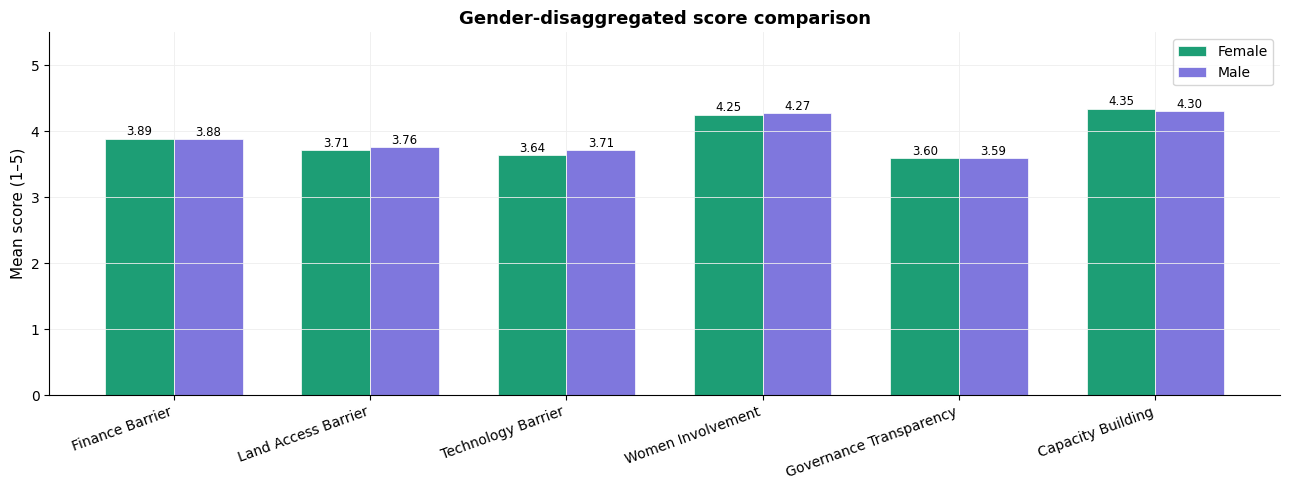


Gender gap (Female − Male):
Capacity Building          0.043001
Finance Barrier            0.005416
Governance Transparency    0.005329
Women Involvement         -0.019990
Land Access Barrier       -0.051581
Technology Barrier        -0.070359


In [ ]:
KEY_SCORES = [
    'Finance_Barrier_Score', 'Land_Access_Barrier_Score',
    'Technology_Barrier_Score', 'Women_Involvement_Score',
    'Governance_Transparency_Score', 'Capacity_Building_Need'
]

gender_means = df.groupby('Gender')[KEY_SCORES].mean().T
gender_means.index = [c.replace('_Score','').replace('_Need','').replace('_',' ') for c in gender_means.index]

x = np.arange(len(gender_means))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x - width/2, gender_means['Female'], width, label='Female',
            color=AfriAgri_GREEN, edgecolor='white', linewidth=0.5)
b2 = ax.bar(x + width/2, gender_means['Male'], width, label='Male',
            color=AfriAgri_PURPLE, edgecolor='white', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(gender_means.index, rotation=20, ha='right')
ax.set_title('Gender-disaggregated score comparison', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean score (1–5)')
ax.set_ylim(0, 5.5)
ax.legend(fontsize=10)

for bar in [*b1, *b2]:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.05,
            f'{h:.2f}', ha='center', fontsize=8.5)

plt.tight_layout()
plt.savefig('fig_10_gender_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nGender gap (Female − Male):')
gap = gender_means['Female'] - gender_means['Male']
print(gap.sort_values(ascending=False).to_string())

In [ ]:
from scipy import stats

print("--- Hypothesis Testing: Rural vs. Urban Women Barriers ---")

# Filter for female respondents
women_df = df[df['Gender'] == 'Female']

# Separate rural and urban women
rural_women = women_df[women_df['Location_Type'] == 'Rural']
urban_women = women_df[women_df['Location_Type'] == 'Urban']

# Check if groups are large enough for meaningful comparison
if len(rural_women) < 2 or len(urban_women) < 2:
    print("Not enough data in one or both groups (rural/urban women) for comparison.")
else:
    print(f"Comparing {len(rural_women)} rural women and {len(urban_women)} urban women.\n")

    for barrier in BARRIER_COLS:
        barrier_name = barrier.replace('_Barrier_Score', '').replace('_Risk_Score', '').replace('_', ' ')

        # Extract scores for rural and urban women
        rural_scores = rural_women[barrier]
        urban_scores = urban_women[barrier]

        # Perform independent samples t-test
        # We assume unequal variances (Welch's t-test) which is often safer
        t_stat, p_value = stats.ttest_ind(rural_scores, urban_scores, equal_var=False)

        print(f"Barrier: {barrier_name}")
        print(f"  Mean score for Rural Women: {rural_scores.mean():.2f}")
        print(f"  Mean score for Urban Women: {urban_scores.mean():.2f}")
        print(f"  T-statistic: {t_stat:.2f}, P-value: {p_value:.3f}")

        alpha = 0.05 # Significance level
        if p_value < alpha:
            if rural_scores.mean() > urban_scores.mean():
                print(f"  Conclusion: Rural women face *significantly higher* {barrier_name.lower()} (p < {alpha}).")
            else:
                print(f"  Conclusion: Urban women face *significantly higher* {barrier_name.lower()} (p < {alpha}).")
        else:
            print(f"  Conclusion: No significant difference in {barrier_name.lower()} between rural and urban women (p >= {alpha}).")
        print("-" * 50)


print("\n--- Further Hypothesis Testing Ideas ---")
print("Consider similar comparisons for:")
print("- Women with Disability vs. Women without Disability")
print("- Different Age Ranges (e.g., 18-35 vs. 36-45)")
print("- Specific Organization Types")
print("For categorical variables like 'Disability_Status' and 'Gender' against scores, or comparing proportions, we might use Chi-squared tests or Mann-Whitney U tests depending on data distribution and question.")


--- Hypothesis Testing: Rural vs. Urban Women Barriers ---
Comparing 917 rural women and 498 urban women.

Barrier: Finance
  Mean score for Rural Women: 3.87
  Mean score for Urban Women: 3.91
  T-statistic: -0.75, P-value: 0.452
  Conclusion: No significant difference in finance between rural and urban women (p >= 0.05).
--------------------------------------------------
Barrier: Land Access
  Mean score for Rural Women: 4.33
  Mean score for Urban Women: 3.16
  T-statistic: 28.23, P-value: 0.000
  Conclusion: Rural women face *significantly higher* land access (p < 0.05).
--------------------------------------------------
Barrier: Climate
  Mean score for Rural Women: 4.43
  Mean score for Urban Women: 3.09
  T-statistic: 30.52, P-value: 0.000
  Conclusion: Rural women face *significantly higher* climate (p < 0.05).
--------------------------------------------------
Barrier: Technology
  Mean score for Rural Women: 4.33
  Mean score for Urban Women: 2.55
  T-statistic: 45.63, P-valu

In [ ]:
from scipy import stats

print("--- Hypothesis Testing: Age Range Barriers (18-35 vs. 60+) ---")

# Define the two age groups for comparison
age_group1_label = '18-35'
age_group2_label = '60+'

# Filter data for the specified age groups
age_group1_df = df[df['Age_Range'] == age_group1_label]
age_group2_df = df[df['Age_Range'] == age_group2_label]

# Check if groups are large enough for meaningful comparison
if len(age_group1_df) < 2 or len(age_group2_df) < 2:
    print(f"Not enough data in one or both age groups ({age_group1_label}/{age_group2_label}) for comparison.")
else:
    print(f"Comparing {len(age_group1_df)} respondents in '{age_group1_label}' and {len(age_group2_df)} respondents in '{age_group2_label}'.\n")

    for barrier in BARRIER_COLS:
        barrier_name = barrier.replace('_Barrier_Score', '').replace('_Risk_Score', '').replace('_', ' ')

        # Extract scores for both age groups
        scores_group1 = age_group1_df[barrier]
        scores_group2 = age_group2_df[barrier]

        # Perform independent samples t-test (Welch's t-test for unequal variances)
        t_stat, p_value = stats.ttest_ind(scores_group1, scores_group2, equal_var=False)

        print(f"Barrier: {barrier_name}")
        print(f"  Mean score for {age_group1_label}: {scores_group1.mean():.2f}")
        print(f"  Mean score for {age_group2_label}: {scores_group2.mean():.2f}")
        print(f"  T-statistic: {t_stat:.2f}, P-value: {p_value:.3f}")

        alpha = 0.05 # Significance level
        if p_value < alpha:
            if scores_group1.mean() > scores_group2.mean():
                print(f"  Conclusion: '{age_group1_label}' respondents face *significantly higher* {barrier_name.lower()} (p < {alpha}).")
            else:
                print(f"  Conclusion: '{age_group2_label}' respondents face *significantly higher* {barrier_name.lower()} (p < {alpha}).")
        else:
            print(f"  Conclusion: No significant difference in {barrier_name.lower()} between '{age_group1_label}' and '{age_group2_label}' respondents (p >= {alpha}).")
        print("-" * 50)

--- Hypothesis Testing: Age Range Barriers (18-35 vs. 60+) ---
Not enough data in one or both age groups (18-35/60+) for comparison.


## 9. Correlation & Composite Intelligence

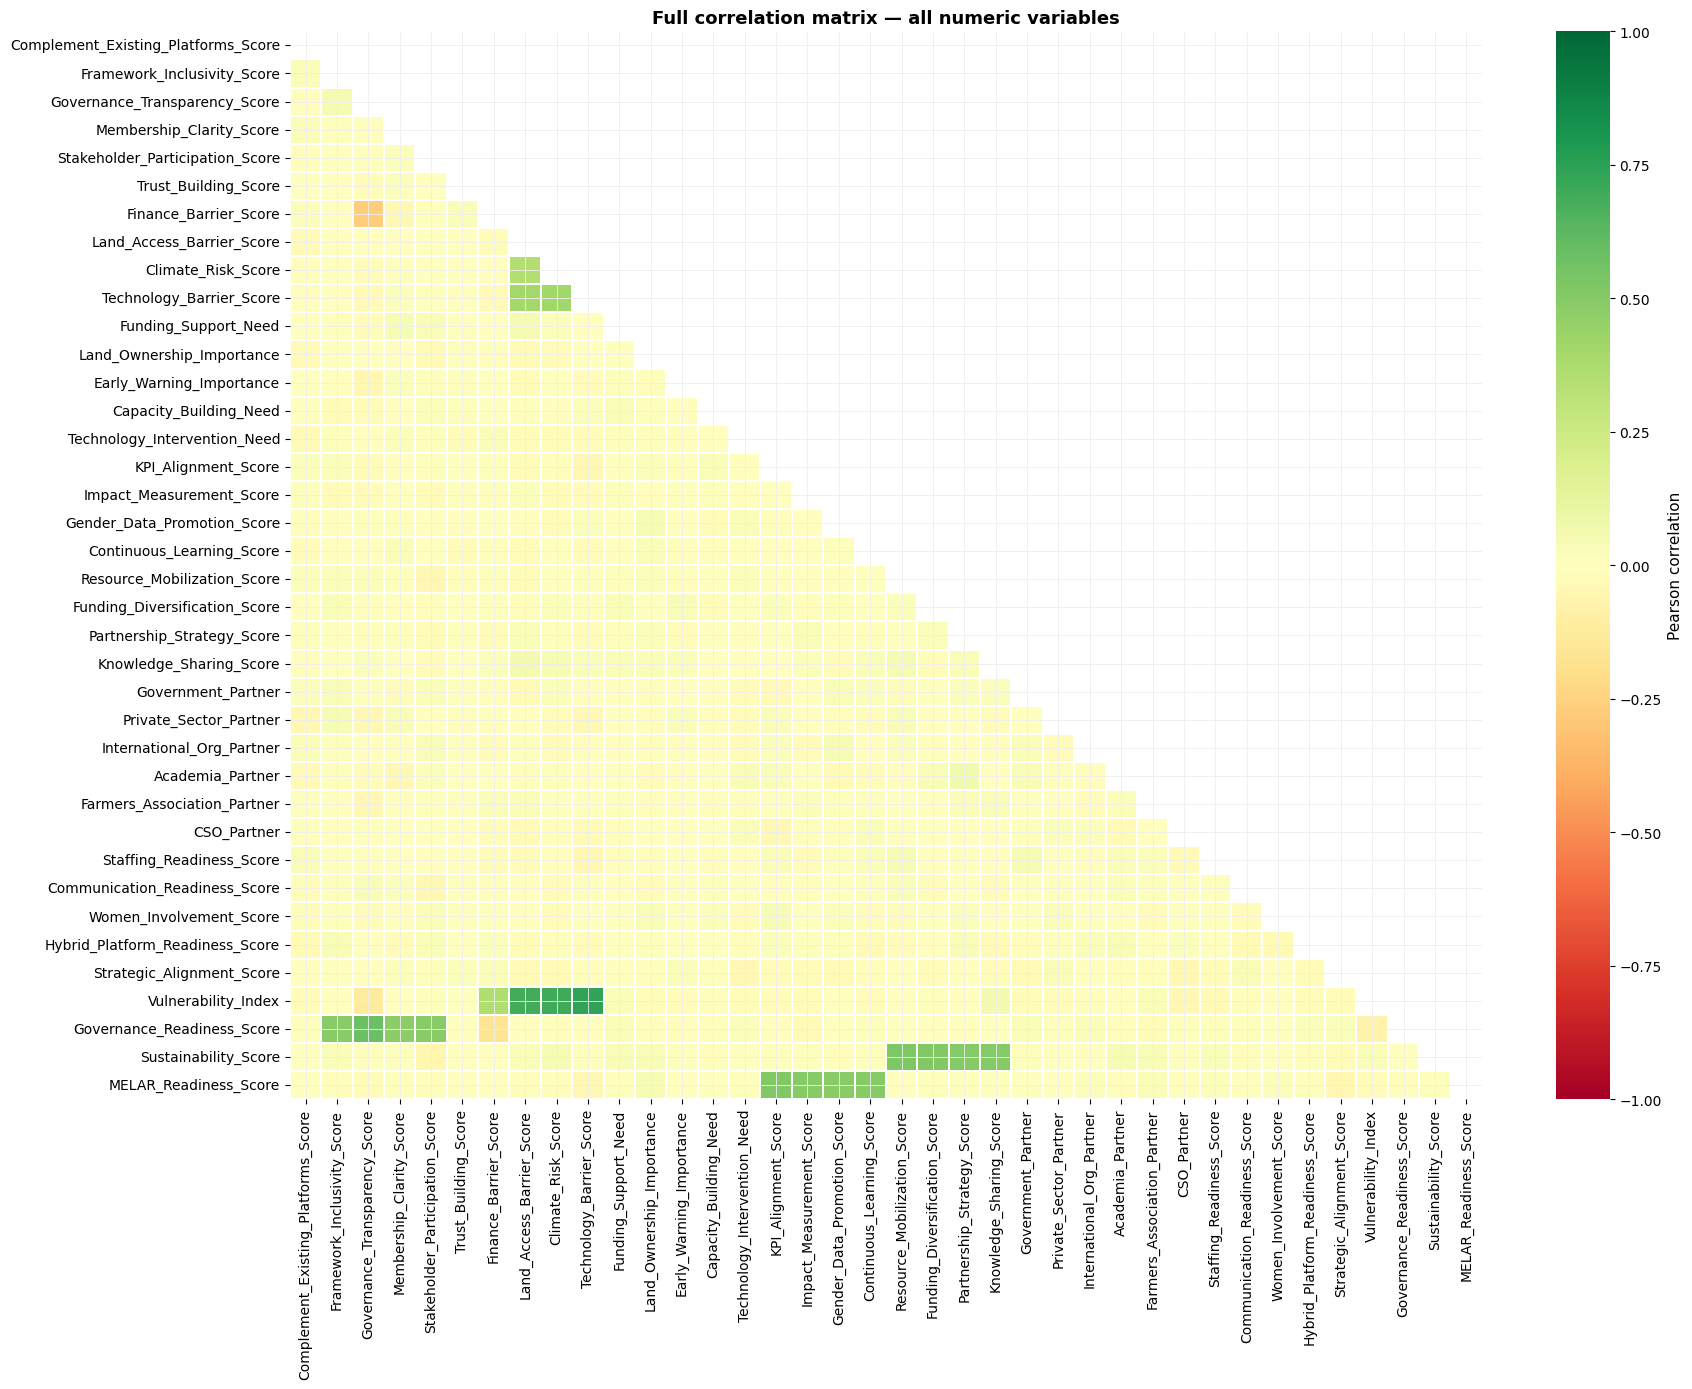

In [ ]:
# ── Full correlation heatmap ───────────────────────────────────────────────
numeric_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=False, cmap='RdYlGn',
    center=0, linewidths=0.3, linecolor='white',
    vmin=-1, vmax=1, ax=ax,
    cbar_kws={'label': 'Pearson correlation'}
)
ax.set_title('Full correlation matrix — all numeric variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_11_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

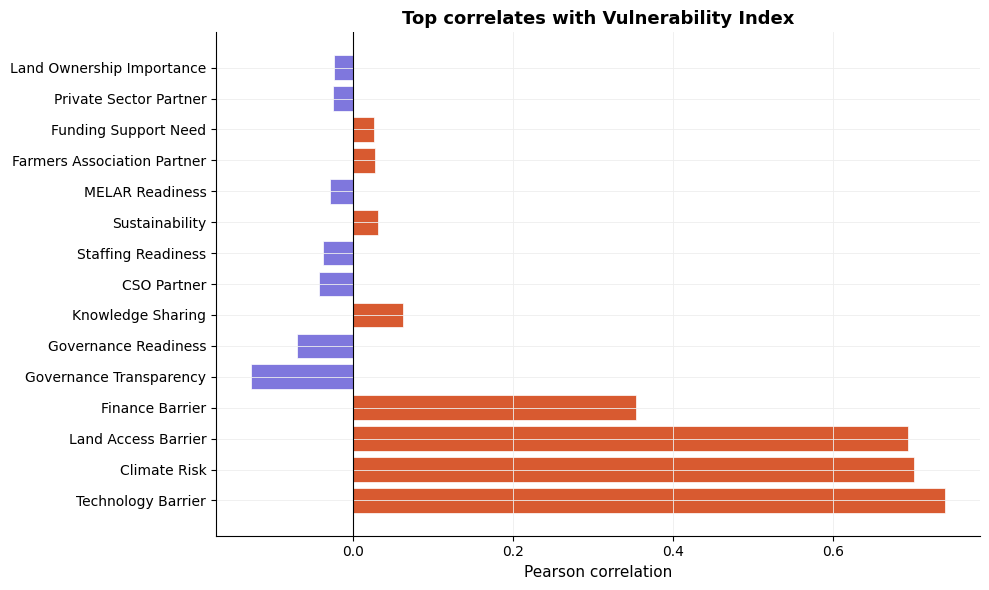

In [ ]:
# ── Top correlates with Vulnerability_Index ────────────────────────────────
vuln_corr = corr['Vulnerability_Index'].drop('Vulnerability_Index').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [AfriAgri_CORAL if v > 0 else AfriAgri_PURPLE for v in vuln_corr.values[:15]]
ax.barh(
    [c.replace('_Score','').replace('_Index','').replace('_',' ') for c in vuln_corr.index[:15]],
    vuln_corr.values[:15],
    color=colors, edgecolor='white', linewidth=0.5
)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top correlates with Vulnerability Index', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson correlation')
plt.tight_layout()
plt.savefig('fig_12_vuln_correlates.png', dpi=150, bbox_inches='tight')
plt.show()

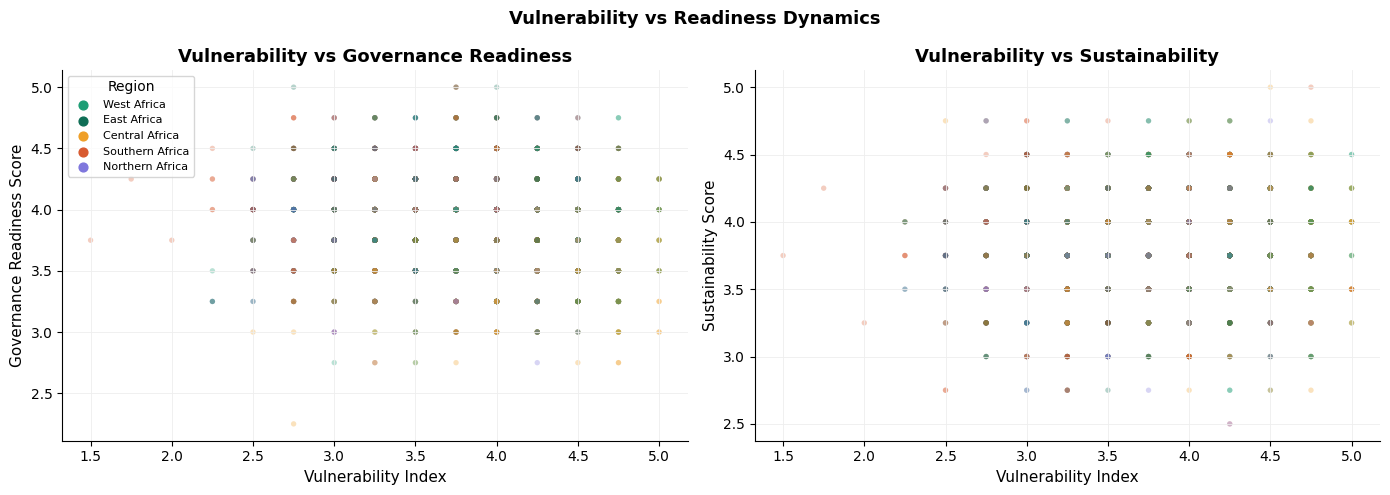

In [ ]:
# ── Scatter: Vulnerability vs Governance Readiness ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Vulnerability vs Readiness Dynamics', fontsize=13, fontweight='bold')

region_colors = df['African_Region'].map(REGION_PALETTE)

axes[0].scatter(df['Vulnerability_Index'], df['Governance_Readiness_Score'],
                c=region_colors, alpha=0.3, s=15, edgecolors='none')
axes[0].set_xlabel('Vulnerability Index')
axes[0].set_ylabel('Governance Readiness Score')
axes[0].set_title('Vulnerability vs Governance Readiness')
for region, color in REGION_PALETTE.items():
    axes[0].scatter([], [], c=color, label=region, s=40)
axes[0].legend(fontsize=8, title='Region')

axes[1].scatter(df['Vulnerability_Index'], df['Sustainability_Score'],
                c=region_colors, alpha=0.3, s=15, edgecolors='none')
axes[1].set_xlabel('Vulnerability Index')
axes[1].set_ylabel('Sustainability Score')
axes[1].set_title('Vulnerability vs Sustainability')

plt.tight_layout()
plt.savefig('fig_13_scatter_composite.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Text Insights — Lessons Learned & Recommendations

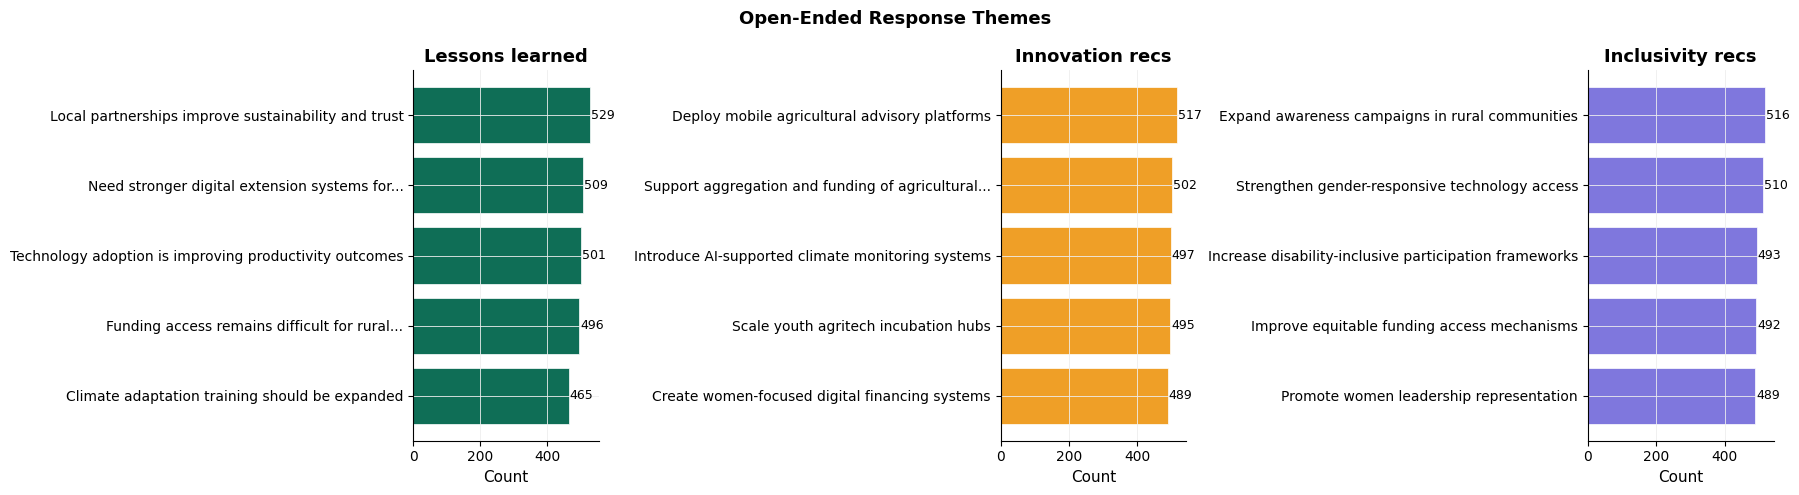

In [ ]:
# ── Frequency of text responses ────────────────────────────────────────────
TEXT_COLS = [
    'Lessons_Learned_Text',
    'Innovation_Recommendations_Text',
    'Inclusivity_Recommendations_Text',
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Open-Ended Response Themes', fontsize=13, fontweight='bold')

colors_text = [AfriAgri_TEAL, AfriAgri_GOLD, AfriAgri_PURPLE]
short_titles = ['Lessons learned', 'Innovation recs', 'Inclusivity recs']

for ax, col, color, title in zip(axes, TEXT_COLS, colors_text, short_titles):
    counts = df[col].value_counts().head(6)
    # Shorten labels for readability
    short_labels = []
    for label in counts.index:
        words = label.split()
        short_labels.append(' '.join(words[:6]) + ('...' if len(words) > 6 else ''))
    bars = ax.barh(short_labels, counts.values, color=color,
                   edgecolor='white', linewidth=0.5)
    ax.set_title(title)
    ax.set_xlabel('Count')
    ax.invert_yaxis()
    for bar, val in zip(bars, counts.values):
        ax.text(val + 3, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig_14_text_themes.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print("--- Regional Partnership Preferences (Proportion per Region) ---")
# Calculate the proportion of respondents in each region who engage with each partner type.
# The partner columns are binary (0=no, 1=yes), so the mean directly gives the proportion.

# Using pd.crosstab to count occurrences and then normalizing by index
partnership_preference = pd.DataFrame()
for partner_col in PARTNER_COLS:
    crosstab_result = pd.crosstab(
        index=df['African_Region'],
        columns=df[partner_col],
        normalize='index' # Normalize by row to get proportions per region
    )
    if 1 in crosstab_result.columns: # Check if '1' (partnered) column exists
        partnership_preference[partner_col.replace('_Partner','').replace('_',' ')] = crosstab_result[1]
    else:
        # If no respondents in a region selected this partner, it might not have a '1' column
        partnership_preference[partner_col.replace('_Partner','').replace('_',' ')] = 0.0 # Assign 0 proportion

print(partnership_preference.round(3).to_string())
print("\n")

print("--- Regional Barrier Proneness (Proportion per Region) ---")
# To identify regions prone to each barrier, we'll consider a score of 4 or 5 as 'prone'.
# We create temporary binary columns for each barrier and then use crosstab.

barrier_proneness = pd.DataFrame()
for barrier_col in BARRIER_COLS:
    # Create a temporary column indicating if a respondent is 'prone' to this barrier
    # 1 if score >= 4, 0 otherwise
    df[f'{barrier_col}_Prone'] = (df[barrier_col] >= 4).astype(int)

    crosstab_result = pd.crosstab(
        index=df['African_Region'],
        columns=df[f'{barrier_col}_Prone'],
        normalize='index' # Normalize by row to get proportions per region
    )
    if 1 in crosstab_result.columns: # Check if '1' (prone) column exists
        barrier_proneness[barrier_col.replace('_Barrier_Score','').replace('_Risk_Score','').replace('_',' ')] = crosstab_result[1]
    else:
        # If no respondents in a region are 'prone' to this barrier, it might not have a '1' column
        barrier_proneness[barrier_col.replace('_Barrier_Score','').replace('_Risk_Score','').replace('_',' ')] = 0.0 # Assign 0 proportion

    # Drop the temporary column to keep the DataFrame clean
    df.drop(columns=[f'{barrier_col}_Prone'], inplace=True)

print(barrier_proneness.round(3).to_string())


--- Regional Partnership Preferences (Proportion per Region) ---
                 Government  Private Sector  International Org  Academia  Farmers Association    CSO
African_Region                                                                                      
Central Africa        0.504           0.522              0.476     0.506                0.519  0.511
East Africa           0.564           0.528              0.454     0.508                0.474  0.501
Northern Africa       0.529           0.535              0.503     0.505                0.513  0.523
Southern Africa       0.548           0.500              0.485     0.466                0.439  0.513
West Africa           0.498           0.535              0.537     0.496                0.461  0.512


--- Regional Barrier Proneness (Proportion per Region) ---
                 Finance  Land Access  Climate  Technology
African_Region                                            
Central Africa     0.931        0.574    0.696   

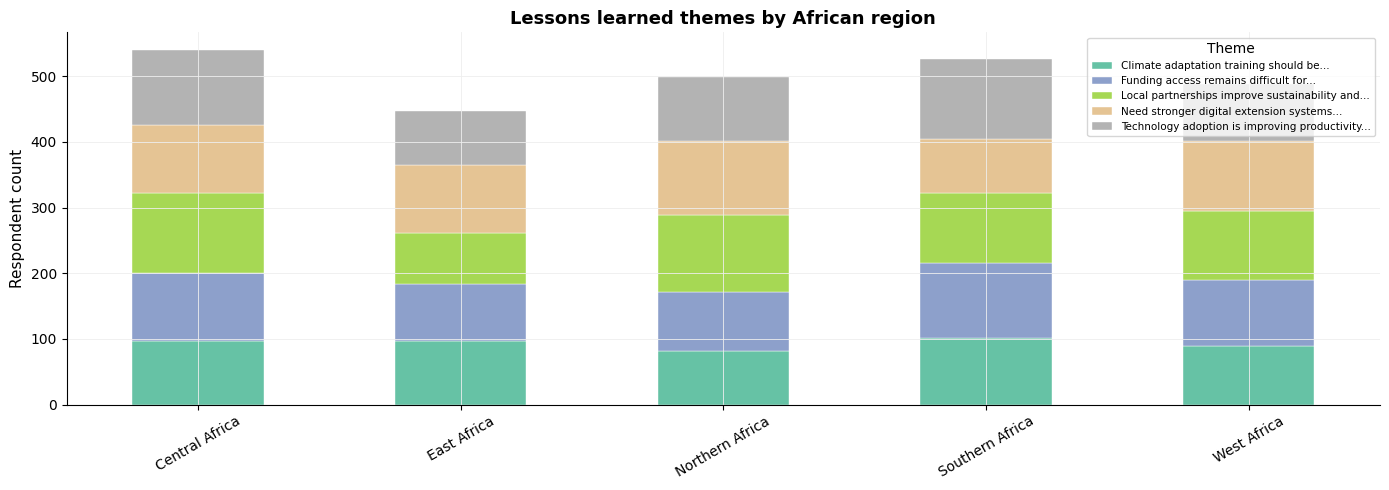

In [ ]:
# ── Text themes vs region (cross-tab) ─────────────────────────────────────
lessons_region = (
    df.groupby(['African_Region', 'Lessons_Learned_Text'])
      .size().unstack(fill_value=0)
)
# Shorten column labels
lessons_region.columns = [' '.join(c.split()[:5]) + '...' for c in lessons_region.columns]

fig, ax = plt.subplots(figsize=(14, 5))
lessons_region.plot(kind='bar', ax=ax, stacked=True,
                    colormap='Set2', edgecolor='white', linewidth=0.3)
ax.set_title('Lessons learned themes by African region', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Respondent count')
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=7.5, loc='upper right', title='Theme')
plt.tight_layout()
plt.savefig('fig_15_text_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Key Findings Summary

In [ ]:
# ── Auto-generate key findings ────────────────────────────────────────────
top_barrier       = df[BARRIER_COLS].mean().idxmax().replace('_Score','').replace('_',' ')
lowest_readiness  = readiness_means.idxmin().replace('_Score','').replace('_',' ')
highest_vuln      = df.groupby('African_Region')['Vulnerability_Index'].mean().idxmax()
critical_count    = (df['Intervention_Priority'] == 'Critical').sum()
high_count        = (df['Intervention_Priority'] == 'High').sum()
top_lesson        = df['Lessons_Learned_Text'].value_counts().index[0]
top_innovation    = df['Innovation_Recommendations_Text'].value_counts().index[0]

print('='*65)
print('   AfriAgri SURVEY EDA — KEY FINDINGS')
print('='*65)
print(f'\n Dataset: {len(df):,} respondents | {df["Country"].nunique()} countries | 5 regions')
print(f'\n1. HIGHEST BARRIER:     {top_barrier}')
print(f'   Mean score: {df[BARRIER_COLS].mean().max():.2f}/5.0')
print(f'\n2. LOWEST READINESS:    {lowest_readiness}')
print(f'   Mean score: {readiness_means.min():.2f}/5.0')
print(f'\n3. MOST VULNERABLE REGION: {highest_vuln}')
print(f'   Mean Vulnerability Index: {df.groupby("African_Region")["Vulnerability_Index"].mean().max():.2f}')
print(f'\n4. INTERVENTION URGENCY:')
print(f'   Critical: {critical_count} respondents ({critical_count/len(df)*100:.1f}%)')
print(f'   High:     {high_count} respondents ({high_count/len(df)*100:.1f}%)')
print(f'   Combined critical/high: {critical_count+high_count} ({(critical_count+high_count)/len(df)*100:.1f}%)')
print(f'\n5. DOMINANT LESSON LEARNED:')
print(f'   "{top_lesson}"')
print(f'\n6. TOP INNOVATION RECOMMENDATION:')
print(f'   "{top_innovation}"')
print(f'\n7. GENDER BREAKDOWN: {df["Gender"].value_counts()["Female"]} Female '
      f'({df["Gender"].value_counts()["Female"]/len(df)*100:.1f}%) | '
      f'{df["Gender"].value_counts()["Male"]} Male '
      f'({df["Gender"].value_counts()["Male"]/len(df)*100:.1f}%)')
print('\n' + '='*65)

   AfriAgri SURVEY EDA — KEY FINDINGS

 Dataset: 2,500 respondents | 20 countries | 5 regions

1. HIGHEST BARRIER:     Climate Risk
   Mean score: 3.94/5.0

2. LOWEST READINESS:    Governance Transparency
   Mean score: 3.60/5.0

3. MOST VULNERABLE REGION: Central Africa
   Mean Vulnerability Index: 3.97

4. INTERVENTION URGENCY:
   Critical: 432 respondents (17.3%)
   High:     1126 respondents (45.0%)
   Combined critical/high: 1558 (62.3%)

5. DOMINANT LESSON LEARNED:
   "Local partnerships improve sustainability and trust"

6. TOP INNOVATION RECOMMENDATION:
   "Deploy mobile agricultural advisory platforms"

7. GENDER BREAKDOWN: 1991 Female (79.6%) | 509 Male (20.4%)



In [ ]:
# ── Export clean analysis-ready dataset ───────────────────────────────────
df.to_csv('afriagri_clean.csv', index=False)
print(f'Clean dataset exported: afriagri_clean.csv ({df.shape[0]:,} rows × {df.shape[1]} cols)')
print('PII removed. Ready for ML pipeline.')